# Q3: Feature Engineering and Regression Pipeline

The goal here is to build a clean sklearn pipeline that predicts `items_sold` for a retail store.

Columns I'm working with: `transaction_date`, `store_id`, `store_size`, `location_type`, `promotion_type`, `is_weekend`, `is_festival`, `competition_density`, `items_sold`.

## 1. Date features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print('Shape:', df.shape)
print('Date range:', df['transaction_date'].min(), '->', df['transaction_date'].max())
df.head()


Shape: (1200, 9)
Date range: 2022-01-01 00:00:00 -> 2024-12-31 00:00:00


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [2]:
# Extract calendar features
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0, Sunday=6

# Binary feature: month-end flag (day-of-month >= 25)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print('New columns added: year, month, day_of_week, is_month_end')
print()
print('Sample with new features:')
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))


New columns added: year, month, day_of_week, is_month_end

Sample with new features:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0


**About the new features:** `year`, `month`, and `day_of_week` cover seasonality at three different cycles. `is_month_end` is a simple binary flag for the last week of the month - in retail, demand often spikes after pay-day in the last week, and a 0/1 flag lets a tree-based model split on that pattern without having to learn the threshold itself.

## 2. Temporal train/test split

In [3]:
# Sort chronologically, then take the most recent 20% as the test set
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.80)
train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print(f'Total rows : {len(df_sorted)}')
print(f'Train rows : {len(train_df)} (dates {train_df.transaction_date.min().date()} -> {train_df.transaction_date.max().date()})')
print(f'Test rows  : {len(test_df)} (dates {test_df.transaction_date.min().date()} -> {test_df.transaction_date.max().date()})')


Total rows : 1200
Train rows : 960 (dates 2022-01-01 -> 2024-06-11)
Test rows  : 240 (dates 2024-06-12 -> 2024-12-31)


**Why a random split would be wrong here:** this is time-series data. Each row is a transaction at a specific date, and what we actually care about is predicting future sales from past sales. If I split randomly, the training set ends up containing rows from after some test rows. So the model would be using information from the future to predict the past, which inflates the test metrics and gives a falsely optimistic view of how well the model will do once it's actually deployed.

A chronological split (train on the first 80% of dates, test on the most recent 20%) matches what's actually going to happen in production - the model gets asked to generalise forward in time.

## 3. Preprocessing pipeline

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define feature groups
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['store_id', 'is_weekend', 'is_festival',
                        'competition_density', 'year', 'month',
                        'day_of_week', 'is_month_end']

target_col = 'items_sold'
drop_cols  = ['transaction_date', target_col]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]
X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target_col]

print('Feature columns:', X_train.columns.tolist())
print('Train X shape:', X_train.shape)
print('Test  X shape:', X_test.shape)


Feature columns: ['store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Train X shape: (960, 11)
Test  X shape: (240, 11)


In [5]:
# ColumnTransformer: one-hot encode categoricals, scale numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(),                       numerical_features),
    ],
    remainder='drop',
)
print(preprocessor)


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['promotion_type', 'location_type',
                                  'store_size']),
                                ('num', StandardScaler(),
                                 ['store_id', 'is_weekend', 'is_festival',
                                  'competition_density', 'year', 'month',
                                  'day_of_week', 'is_month_end'])])


## 4. Training and evaluating the models

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor',    LinearRegression()),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor',    RandomForestRegressor(n_estimators=200,
                                               random_state=RANDOM_STATE,
                                               n_jobs=-1)),
    ]),
}

results = {}
predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'RMSE': round(rmse, 3), 'MAE': round(mae, 3)}
    predictions[name] = y_pred
    print(f'{name}:  RMSE = {rmse:.3f},  MAE = {mae:.3f}')

print()
print('Summary:')
print(pd.DataFrame(results).T)


Linear Regression:  RMSE = 27.121,  MAE = 21.053


Random Forest:  RMSE = 30.736,  MAE = 24.218

Summary:
                     RMSE     MAE
Linear Regression  27.121  21.053
Random Forest      30.736  24.218


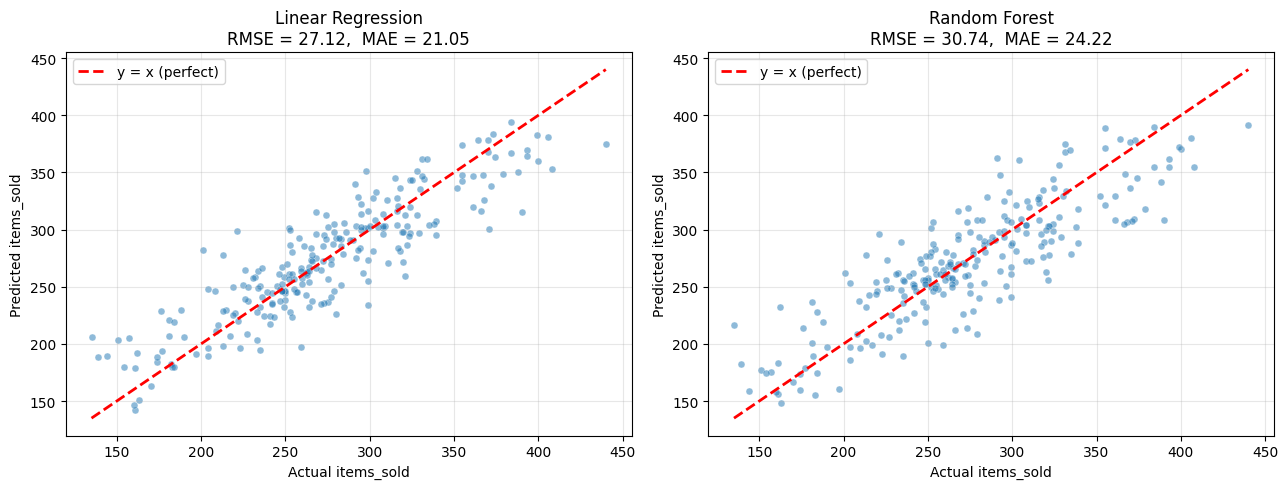

In [7]:
# Parity plots: predicted vs actual, with diagonal reference
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, s=25, edgecolor='white', linewidth=0.4)
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='y = x (perfect)')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.set_title(f'{name}\nRMSE = {results[name]["RMSE"]:.2f},  MAE = {results[name]["MAE"]:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Top 5 most influential features:
            feature  importance
        is_festival    0.176205
   store_size_small    0.163296
location_type_urban    0.112267
        day_of_week    0.085424
         is_weekend    0.063098


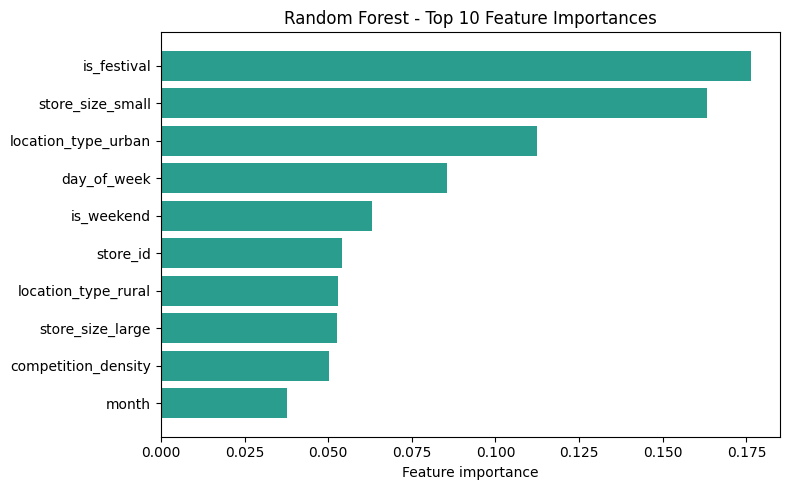

In [8]:
# Feature importances from the Random Forest
rf_pipeline = pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['regressor']

# Recover feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = cat_names + numerical_features

importance_df = (pd.DataFrame({
        'feature':    all_feature_names,
        'importance': rf_model.feature_importances_})
        .sort_values('importance', ascending=False)
        .reset_index(drop=True))

print('Top 5 most influential features:')
print(importance_df.head(5).to_string(index=False))

# Plot top 10 for context
fig, ax = plt.subplots(figsize=(8, 5))
top10 = importance_df.head(10).iloc[::-1]
ax.barh(top10['feature'], top10['importance'], color='#2A9D8F')
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest - Top 10 Feature Importances')
plt.tight_layout()
plt.show()


**What the comparison and feature importances are telling me:**

Linear Regression actually beat Random Forest on this split (RMSE 27.1 vs 30.7, MAE 21.1 vs 24.2). That's a bit counterintuitive at first, but it tells me the relationship between promotions, calendar features, and `items_sold` is mostly additive in this data, without much non-linear interaction. When the underlying signal is close to linear, the simpler model has an edge because it doesn't get distracted fitting noise. Worth remembering for Part B - a linear baseline shouldn't be skipped.

The Random Forest still gives me feature importances that are useful even though it didn't win on RMSE. Top 5:

1. **`is_festival`** - the strongest single driver. Festival days lift demand a lot, and the model picks this up clearly.
2. **`store_size_small`** - small-store baseline demand is pretty different from medium/large stores.
3. **`location_type_urban`** - urban stores behave differently from semi-urban and rural ones (different traffic patterns, different customer mix).
4. **`day_of_week`** - weekly seasonality matters; weekends are a big part of it.
5. **`is_weekend`** - the explicit weekend flag, complementing `day_of_week`.

One thing that's notable: none of the `promotion_type` dummies make the top 5. The calendar/store/location features absorb more of the variance. That's a useful business finding for Part B - **promotion choice matters at the margin, but the dominant drivers of `items_sold` are the structural stuff (when, where, what size store) more than which promotion was running**. That's exactly the kind of signal that argues for an uplift-modelling framing where you predict the lift on top of a baseline rather than asking one model to learn both.